In [2]:
import torch
torch.__version__

'2.5.1+cpu'

In [3]:
import tqdm as notebook_tqdm

In [4]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
KMP_DUPLICATE_LIB_OK=True

In [1]:
#!pip install ultralytics==8.0.20

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics 8.3.130  Python-3.12.3 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Setup complete  (12 CPUs, 7.7 GB RAM, 119.5/237.6 GB disk)


In [3]:
from ultralytics import YOLO
from PIL import Image

from IPython.display import display, Image

In [7]:
dataset = 'C:/Users/PMLS/Downloads/MultispectralData/BigMS/'

In [11]:

import os
from random import choice
import shutil

#arrays to store file names
imgs =[]
xmls =[]

#setup dir names
trainPath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/images/train'
valPath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/images/val'
crsPath = 'C:/Users/PMLS/Downloads/MultispectralData/BigMS/' #dir where images and annotations stored

#setup ratio (val ratio = rest of the files in origin dir after splitting into train and test)
train_ratio = 0.75
val_ratio = 0.25


#total count of imgs
totalImgCount = len(os.listdir(crsPath))/2

#soring files to corresponding arrays
for (dirname, dirs, files) in os.walk(crsPath):
    for filename in files:
        if filename.endswith('.txt'):
            xmls.append(filename)
        else:
            imgs.append(filename)


#counting range for cycles
countForTrain = int(len(imgs)*train_ratio)
countForVal = int(len(imgs)*val_ratio)
print("training images are : ",countForTrain)
print("Validation images are : ",countForVal)


training images are :  108
Validation images are :  36


In [8]:
trainimagePath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/images/train/'
trainlabelPath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/labels/train/'
valimagePath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/images/val/'
vallabelPath = 'C:/Users/PMLS/Desktop/ALL ETC/Downloads/Yolo_Books_Mine/Yolo8 NIR/Ultra/datasets/labels/val/'

#cycle for train dir
for x in range(countForTrain):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    #shutil.move(os.path.join(crsPath, fileJpg), os.path.join(trainimagePath, fileJpg))
    #shutil.move(os.path.join(crsPath, fileXml), os.path.join(trainlabelPath, fileXml))
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(trainimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(trainlabelPath, fileXml))


    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)


#cycle for test dir   
for x in range(countForVal):

    fileJpg = choice(imgs) # get name of random image from origin dir
    fileXml = fileJpg[:-4] +'.txt' # get name of corresponding annotation file

    #move both files into train dir
    #shutil.move(os.path.join(crsPath, fileJpg), os.path.join(valimagePath, fileJpg))
    #shutil.move(os.path.join(crsPath, fileXml), os.path.join(vallabelPath, fileXml))
    shutil.copy(os.path.join(crsPath, fileJpg), os.path.join(valimagePath, fileJpg))
    shutil.copy(os.path.join(crsPath, fileXml), os.path.join(vallabelPath, fileXml))
    
    #remove files from arrays
    imgs.remove(fileJpg)
    xmls.remove(fileXml)

#rest of files will be validation files, so rename origin dir to val dir
#os.rename(crsPath, valPath)
shutil.move(crsPath, valPath) 


NameError: name 'countForTrain' is not defined

In [10]:
import ultralytics

In [11]:
%cd {HOME}
!yolo task=segment mode=train model=yolov8n-seg.pt data=segconfig.yaml epochs=2 batch=4 visualize=True show=True imgsz=256 plots=True cache=True 
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8_NIR\Ultra
CPU times: total: 0 ns
Wall time: 0 ns


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\PMLS\anaconda3\Scripts\yolo.exe\__main__.py", line 4, in <module>
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\__init__.py", line 11, in <module>
    from ultralytics.models import NAS, RTDETR, SAM, YOLO, YOLOE, FastSAM, YOLOWorld
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\models\__init__.py", line 3, in <module>
    from .fastsam import FastSAM
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\models\fastsam\__init__.py", line 3, in <module>
    from .model import FastSAM
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\models\fastsam\model.py", line 5, in <module>
    from ultralytics.engine.model import Model
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\engine\model.py", line 12, in <module>
    from ultralytics.engine.results import Results
  File "C:

In [ ]:
model = YOLO('yolov8n-seg.pt')  # load a pretrained model (recommended for training)

model.train(data='segconfig.yaml', epochs=2, imgsz=256)


Ultralytics 8.3.130  Python-3.12.3 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=segconfig.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train23, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=Tr

train: Scanning C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8_NIR\Ultra\datasets\labels\train.cache... 


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.1 ms, read: 184.9156.4 MB/s, size: 790.9 KB)


val: Scanning C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8_NIR\Ultra\datasets\labels\val.cache... 3 im


Plotting labels to runs\segment\train23\labels.jpg... 


In [16]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8m.pt data=NIRdatasetNB.yaml batch=16 epochs=50 imgsz=640 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)CPU times: total: 0 ns
Wall time: 0 ns

engine\trainer: task=detect, mode=train, model=yolov8m.pt, data=NIRdatasetNB.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train25, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False,


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 108 images, 0 backgrounds, 0 corrupt: 100%|##########| 108/108 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 108 images, 0 backgrounds, 0 corrupt: 100%|##########| 108/108 [00:00<?, ?it/s]

train: Caching images (0.1GB RAM): 100%|##########| 108/108 [00:00<00:00, 226.99it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 36 images, 0 backgrounds, 0 corrupt: 100%|##########| 36/36 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 36 images, 0

In [15]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8m.pt data=NIRdatasetNB.yaml batch=32 epochs=50 imgsz=256 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8m.pt, data=NIRdatasetNB.yaml, epochs=50, time=None, patience=100, batch=32, imgsz=256, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train24, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sav


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 108 images, 0 backgrounds, 0 corrupt: 100%|##########| 108/108 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 108 images, 0 backgrounds, 0 corrupt: 100%|##########| 108/108 [00:00<?, ?it/s]

train: Caching images (0.0GB RAM): 100%|##########| 108/108 [00:00<00:00, 207.16it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 36 images, 0 backgrounds, 0 corrupt: 100%|##########| 36/36 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 36 images, 0

In [14]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8m.pt data=NIRdatasetNB.yaml batch=32 epochs=5 imgsz=256 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8m.pt, data=NIRdatasetNB.yaml, epochs=5, time=None, patience=100, batch=32, imgsz=256, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train23, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train...:   0%|          | 0/108 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 1 images, 0 backgrounds, 0 corrupt:   1%|          | 1/108 [00:00<00:19,  5.55it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 31 images, 0 backgrounds, 0 corrupt:  29%|##8       | 31/108 [00:00<00:00, 134.23it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 49 images, 0 backgrounds, 0 corrupt:  45%|####5     | 49/108 [00:00<00:00, 136.26it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 78 images, 0 backgrounds, 0 corrupt:  72%|#######2  | 78/108 [00:00<00:00, 186.19it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 101 images, 0 backgrounds, 0 corrupt:  94%|#########3| 101/108 [00:00<00:00, 188.44it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 108 images, 0 backgrounds, 0 corrupt: 100%|##########| 108/108 [00:00<00:00, 168.53

In [10]:
%time

CPU times: total: 0 ns
Wall time: 0 ns


In [32]:
%cd {HOME}

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


In [8]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data=NIRdatasetNB.yaml batch=16 epochs=50 imgsz=640 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=NIRdatasetNB.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train22, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sav


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train...:   0%|          | 0/39 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 1 images, 0 backgrounds, 0 corrupt:   3%|2         | 1/39 [00:00<00:08,  4.59it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 39 images, 0 backgrounds, 0 corrupt: 100%|##########| 39/39 [00:00<00:00, 127.50it/s]

train: Caching images (0.0GB RAM): 100%|##########| 39/39 [00:00<00:00, 94.49it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val...:   0%|          | 0/15 [00:00<?, ?it/s]
val: Scanning C:\Users\

In [38]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8s.pt data=NIRdatasetNB.yaml batch=16 epochs=25 imgsz=960 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=NIRdatasetNB.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=960, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train17, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, sav


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]

train: Caching images (0.1GB RAM): 100%|##########| 40/40 [00:00<00:00, 101.73it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 0 backgrounds, 0 corrupt: 100%|##########| 13/13 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 0 backgro

In [5]:
###### %cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=NIRdataset.yaml batch=32 epochs=2 imgsz=1024 plots=True cache=True
%time

Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=NIRdataset.yaml, epochs=2, time=None, patience=100, batch=32, imgsz=1024, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train18, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxe


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train...:   0%|          | 0/39 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 1 images, 0 backgrounds, 0 corrupt:   3%|2         | 1/39 [00:00<00:08,  4.34it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 28 images, 0 backgrounds, 0 corrupt:  72%|#######1  | 28/39 [00:00<00:00, 104.75it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 39 images, 0 backgrounds, 0 corrupt: 100%|##########| 39/39 [00:00<00:00, 107.07it/s]

train: Caching images (0.1GB RAM): 100%|##########| 39/39 [00:00<00:00, 78.40it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(

In [7]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=NIRdataset.yaml batch=8 epochs=50 imgsz=640 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)CPU times: total: 0 ns
Wall time: 0 ns

engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=NIRdataset.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train21, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, sa


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train...:   0%|          | 0/39 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 1 images, 0 backgrounds, 0 corrupt:   3%|2         | 1/39 [00:00<00:08,  4.66it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train... 39 images, 0 backgrounds, 0 corrupt: 100%|##########| 39/39 [00:00<00:00, 131.66it/s]

train: Caching images (0.0GB RAM): 100%|##########| 39/39 [00:00<00:00, 110.39it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val...:   0%|          | 0/15 [00:00<?, ?it/s]
val: Scanning C:\Users

In [12]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=NIRdataset.yaml batch=8 epochs=25 imgsz=640 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=NIRdataset.yaml, epochs=25, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train9, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_co


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]

train: Caching images (0.0GB RAM): 100%|##########| 40/40 [00:00<00:00, 145.08it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backgrounds, 0 corrupt: 100%|##########| 67/67 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backg

In [11]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=NIRdataset.yaml batch=8 epochs=2 imgsz=640 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=NIRdataset.yaml, epochs=2, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_con


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]

train: Caching images (0.0GB RAM): 100%|##########| 40/40 [00:00<00:00, 133.67it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backgrounds, 0 corrupt: 100%|##########| 67/67 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backg

In [10]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=NIRdataset.yaml batch=6 epochs=2 imgsz=256 plots=True cache=True
%time

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra
Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=NIRdataset.yaml, epochs=2, time=None, patience=100, batch=32, imgsz=256, save=True, save_period=-1, cache=True, device=None, workers=8, project=None, name=train7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_co


train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]
train: Scanning C:\Users\PMLS\Desktop\datasets\labels\train.cache... 40 images, 0 backgrounds, 0 corrupt: 100%|##########| 40/40 [00:00<?, ?it/s]

train: Caching images (0.0GB RAM): 100%|##########| 40/40 [00:00<00:00, 109.22it/s]
C:\Users\PMLS\anaconda3\Lib\site-packages\albumentations\check_version.py:107: UserWarning: Error fetching version info <urlopen error [Errno 11001] getaddrinfo failed>
  data = fetch_version_info()
C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\data\augment.py:1850: UserWarning: Argument 'quality_lower' is not valid and will be ignored.
  A.ImageCompression(quality_lower=75, p=0.0),

val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backgrounds, 0 corrupt: 100%|##########| 67/67 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backg

In [12]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=dataset.yaml batch=32 epochs=50 imgsz=256 plots=True cache=True time=
%time

C:\Users\HP\Downloads\Yolo_Books_Mine\ultralytics-main
CPU times: total: 0 ns
Wall time: 0 ns


Traceback (most recent call last):
  File "C:\Users\HP\AppData\Local\anaconda3\envs\eden\lib\runpy.py", line 194, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\HP\AppData\Local\anaconda3\envs\eden\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "C:\Users\HP\AppData\Local\anaconda3\envs\eden\Scripts\yolo.exe\__main__.py", line 7, in <module>
  File "C:\Users\HP\AppData\Local\anaconda3\envs\eden\lib\site-packages\ultralytics\cfg\__init__.py", line 381, in entrypoint
    raise SyntaxError(f"'{colorstr('red', 'bold', a)}' is a valid YOLO argument but is missing an '=' sign "
SyntaxError: 'time' is a valid YOLO argument but is missing an '=' sign to set its value, i.e. try 'time=None'

    Arguments received: ['yolo', 'task=detect', 'mode=train', 'model=yolov8n.pt', 'data=dataset.yaml', 'batch=32', 'epochs=50', 'imgsz=256', 'plots=True', 'cache=True', 'time']. Ultralytics 'yolo' commands use the following syntax:

        yolo

In [7]:
%cd {HOME}

!yolo task=detect mode=train model=yolov8n.pt data=dataset.yaml epochs=5 imgsz=224 plots=True

[WinError 2] The system cannot find the file specified: '{HOME}'
C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main
WARNING âš ï¸� Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View settings with 'yolo settings' or at 'C:\Users\HP\AppData\Roaming\Ultralytics\settings.yaml'
Update settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'.
Ultralytics YOLOv8.0.232 ðŸš€ Python-3.8.10 torch-1.8.0+cpu CPU (Intel Core(TM) i5-2520M 2.50GHz)
WARNING âš ï¸� Upgrade to torch>=2.0.0 for deterministic training.
engine\trainer: task=detect, mode=train, model=yolov8n.pt, data=dataset.yaml, epochs=5, time=None, patience=50, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train8, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mos


train: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\labels\train...:   0%|          | 0/220 [00:00<?, ?it/s]
train: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\labels\train... 1 images, 0 backgrounds, 0 corrupt:   0%|          | 1/220 [00:00<00:45,  4.76it/s]
train: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\labels\train... 61 images, 0 backgrounds, 0 corrupt:  28%|##7       | 61/220 [00:00<00:00, 244.85it/s]
train: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\labels\train... 147 images, 0 backgrounds, 0 corrupt:  67%|######6   | 147/220 [00:00<00:00, 466.43it/s]
train: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\labels\train... 220 images, 0 backgrounds, 0 corrupt: 100%|##########| 220/220 [00:00<00:00, 451.01it/s]

val: Scanning C:\Users\HP\Downloads\Yolo Books Mine\ultralytics-main\datasets\dataset\la

In [14]:
%cd {HOME}

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


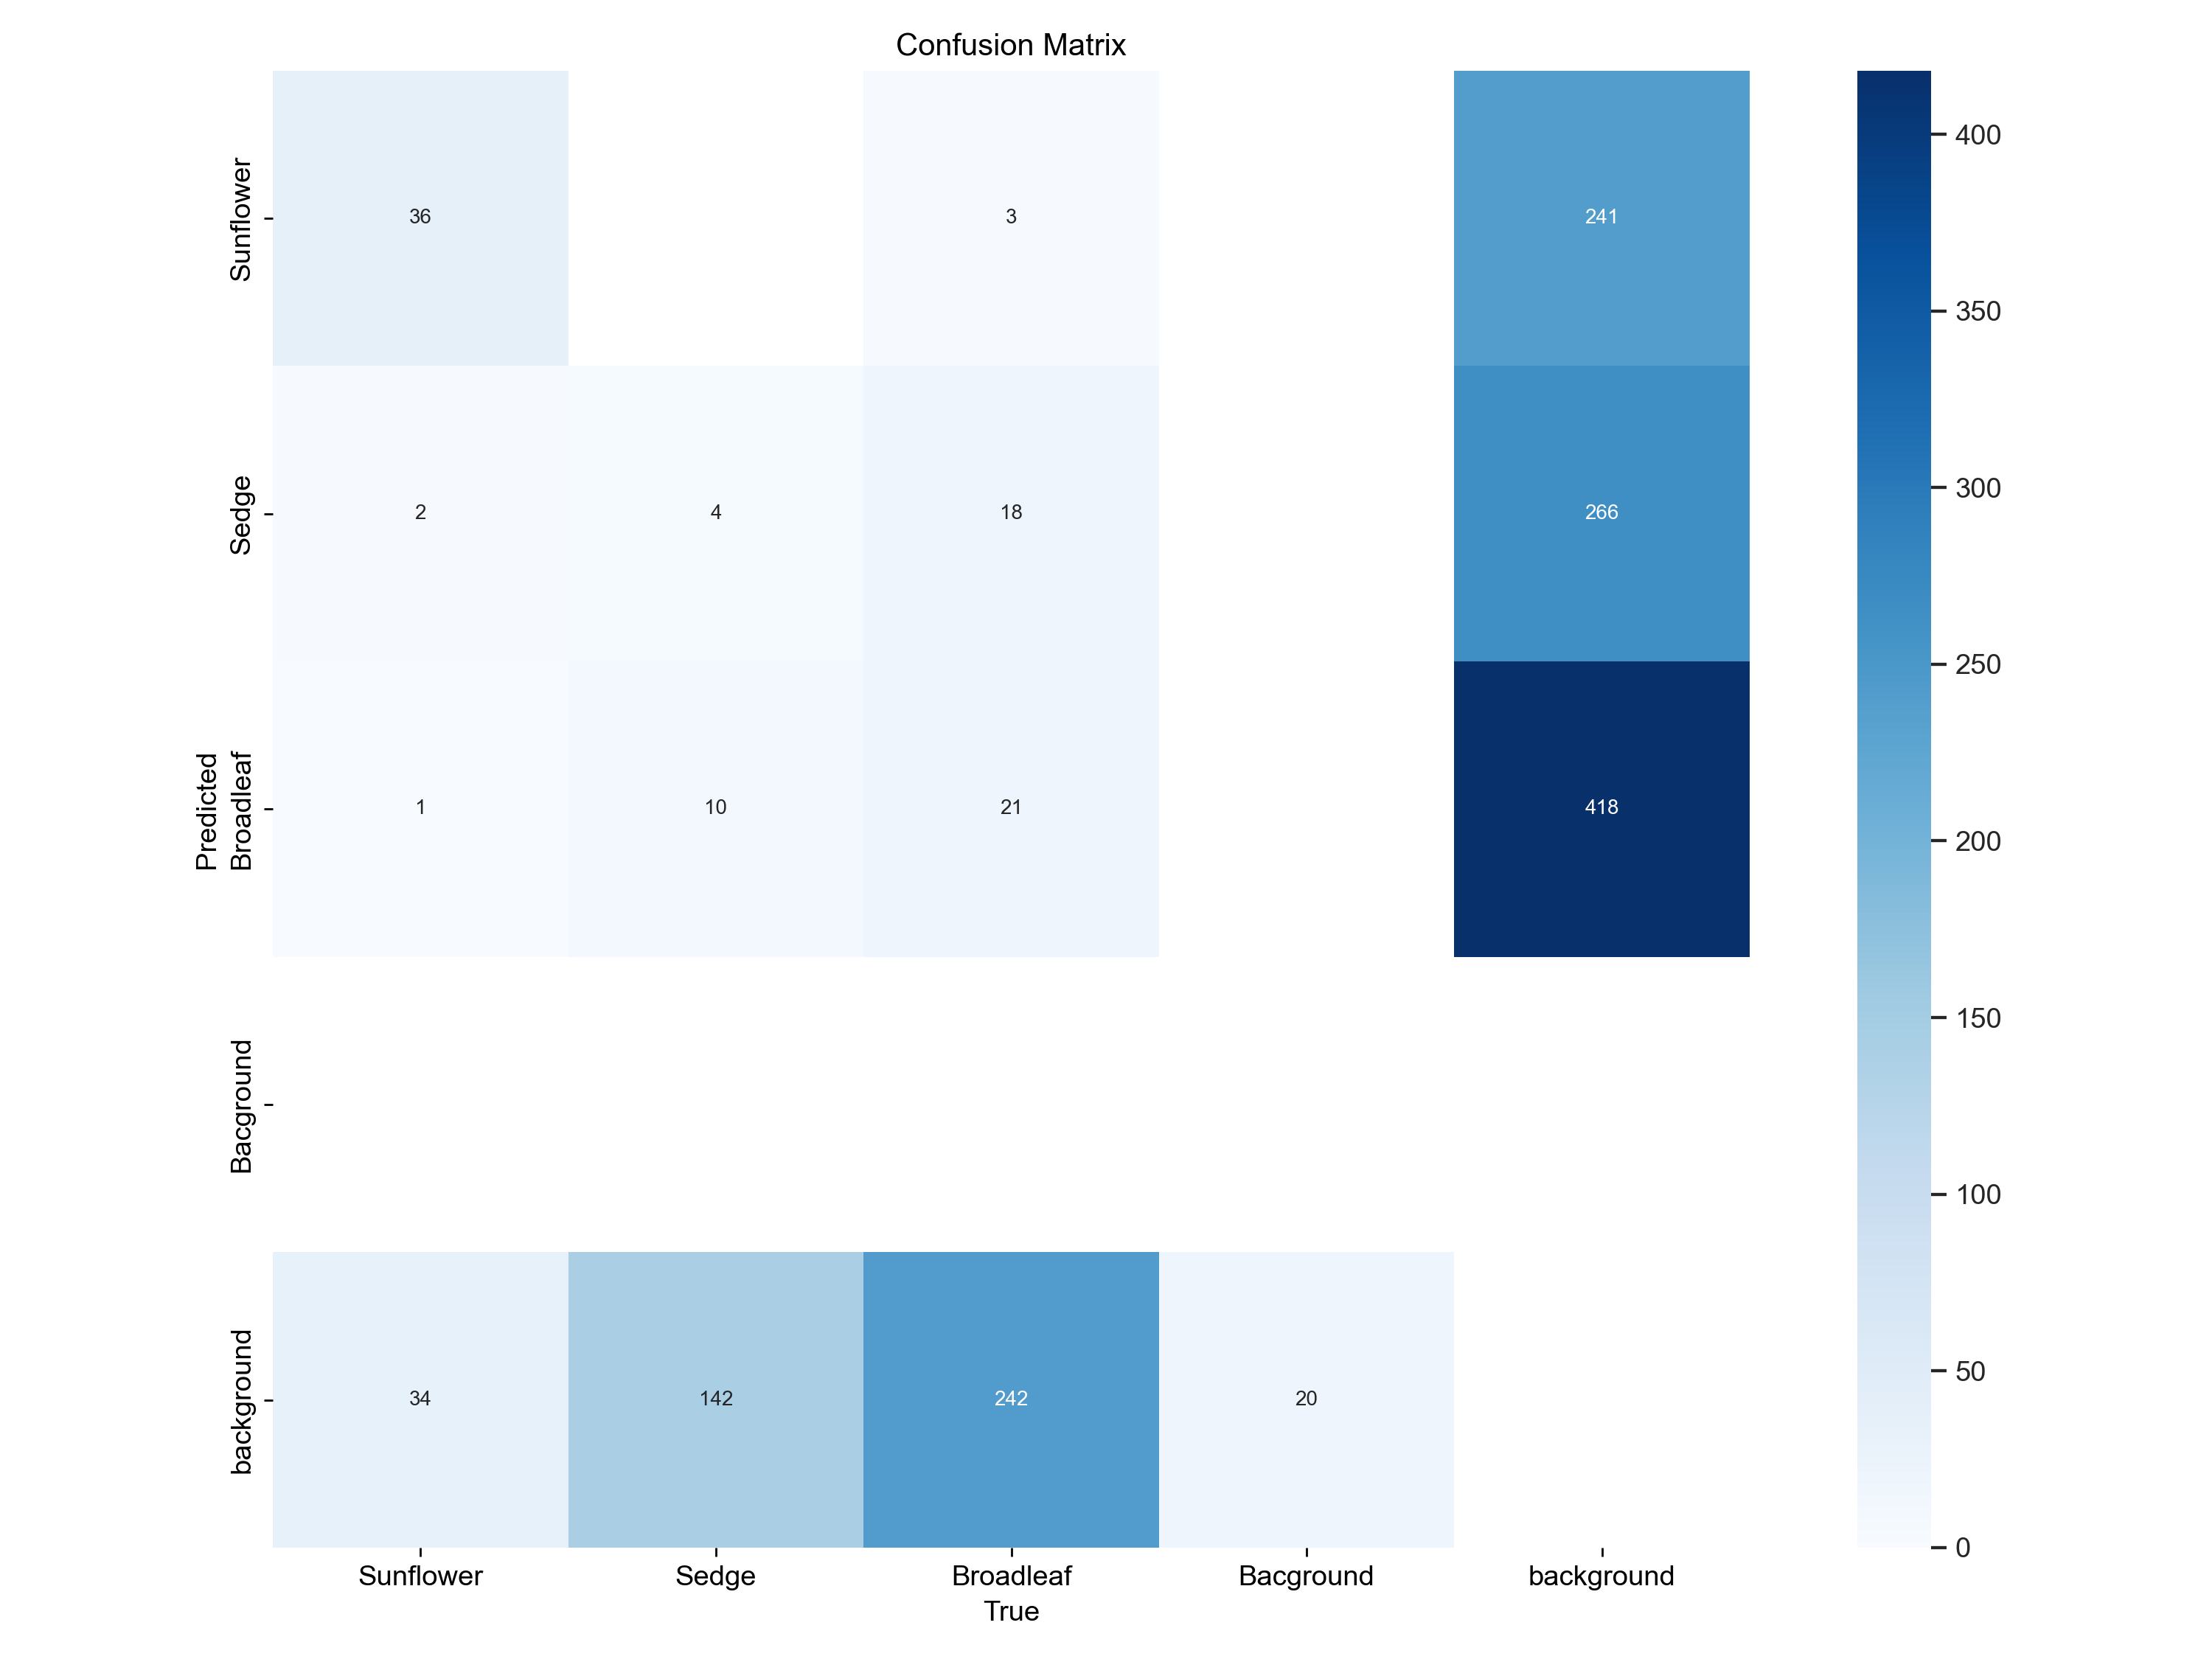

In [16]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train9/confusion_matrix.png', width=600)

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


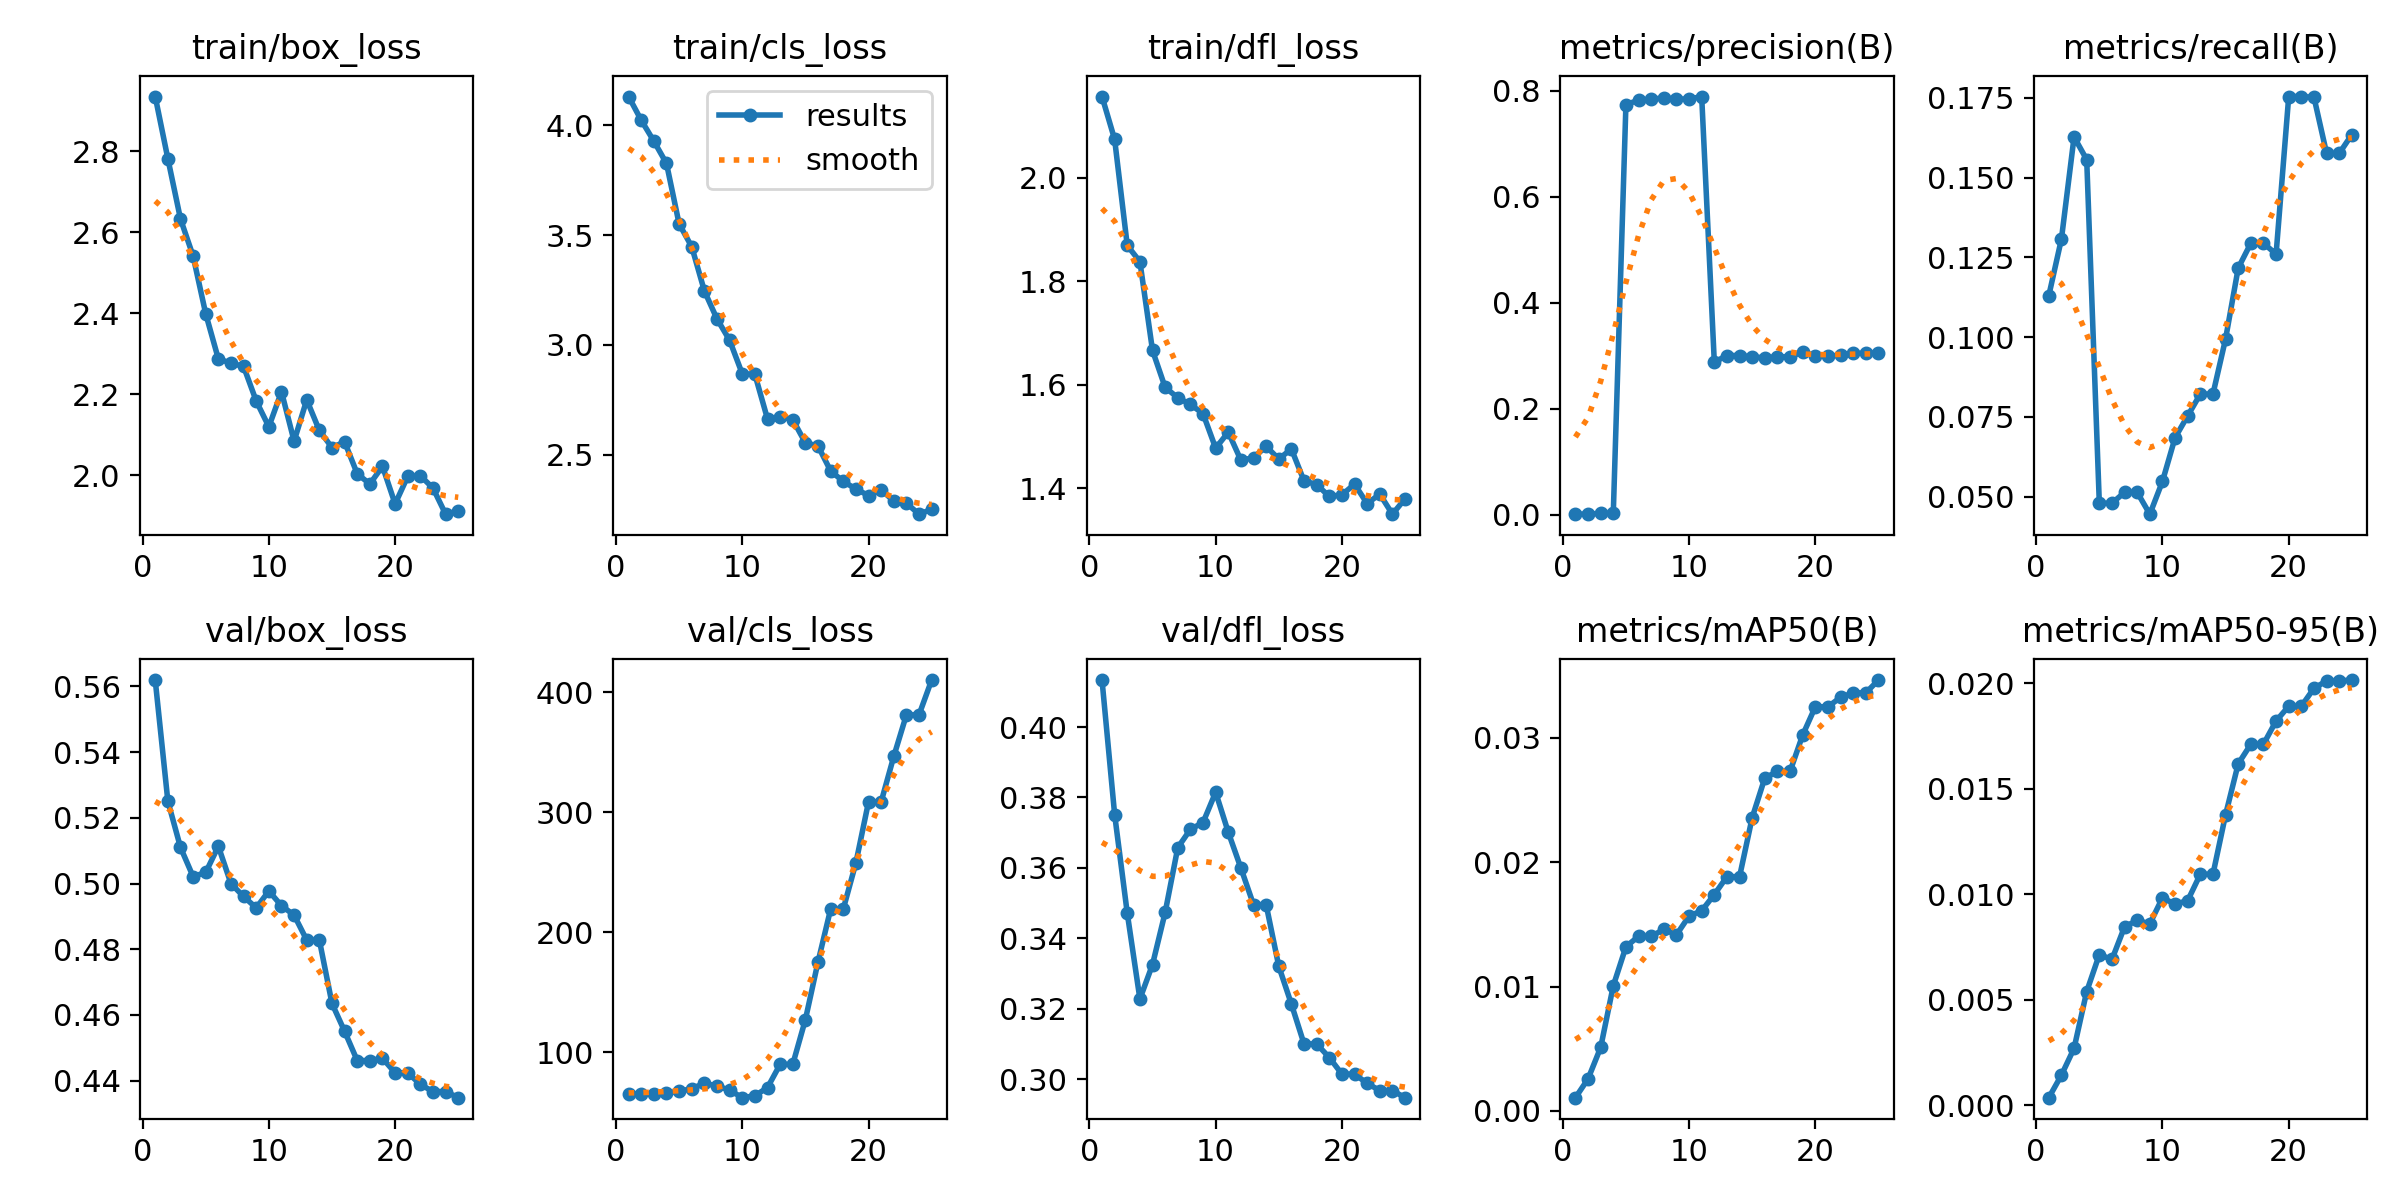

In [17]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train9/results.png', width=600)

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


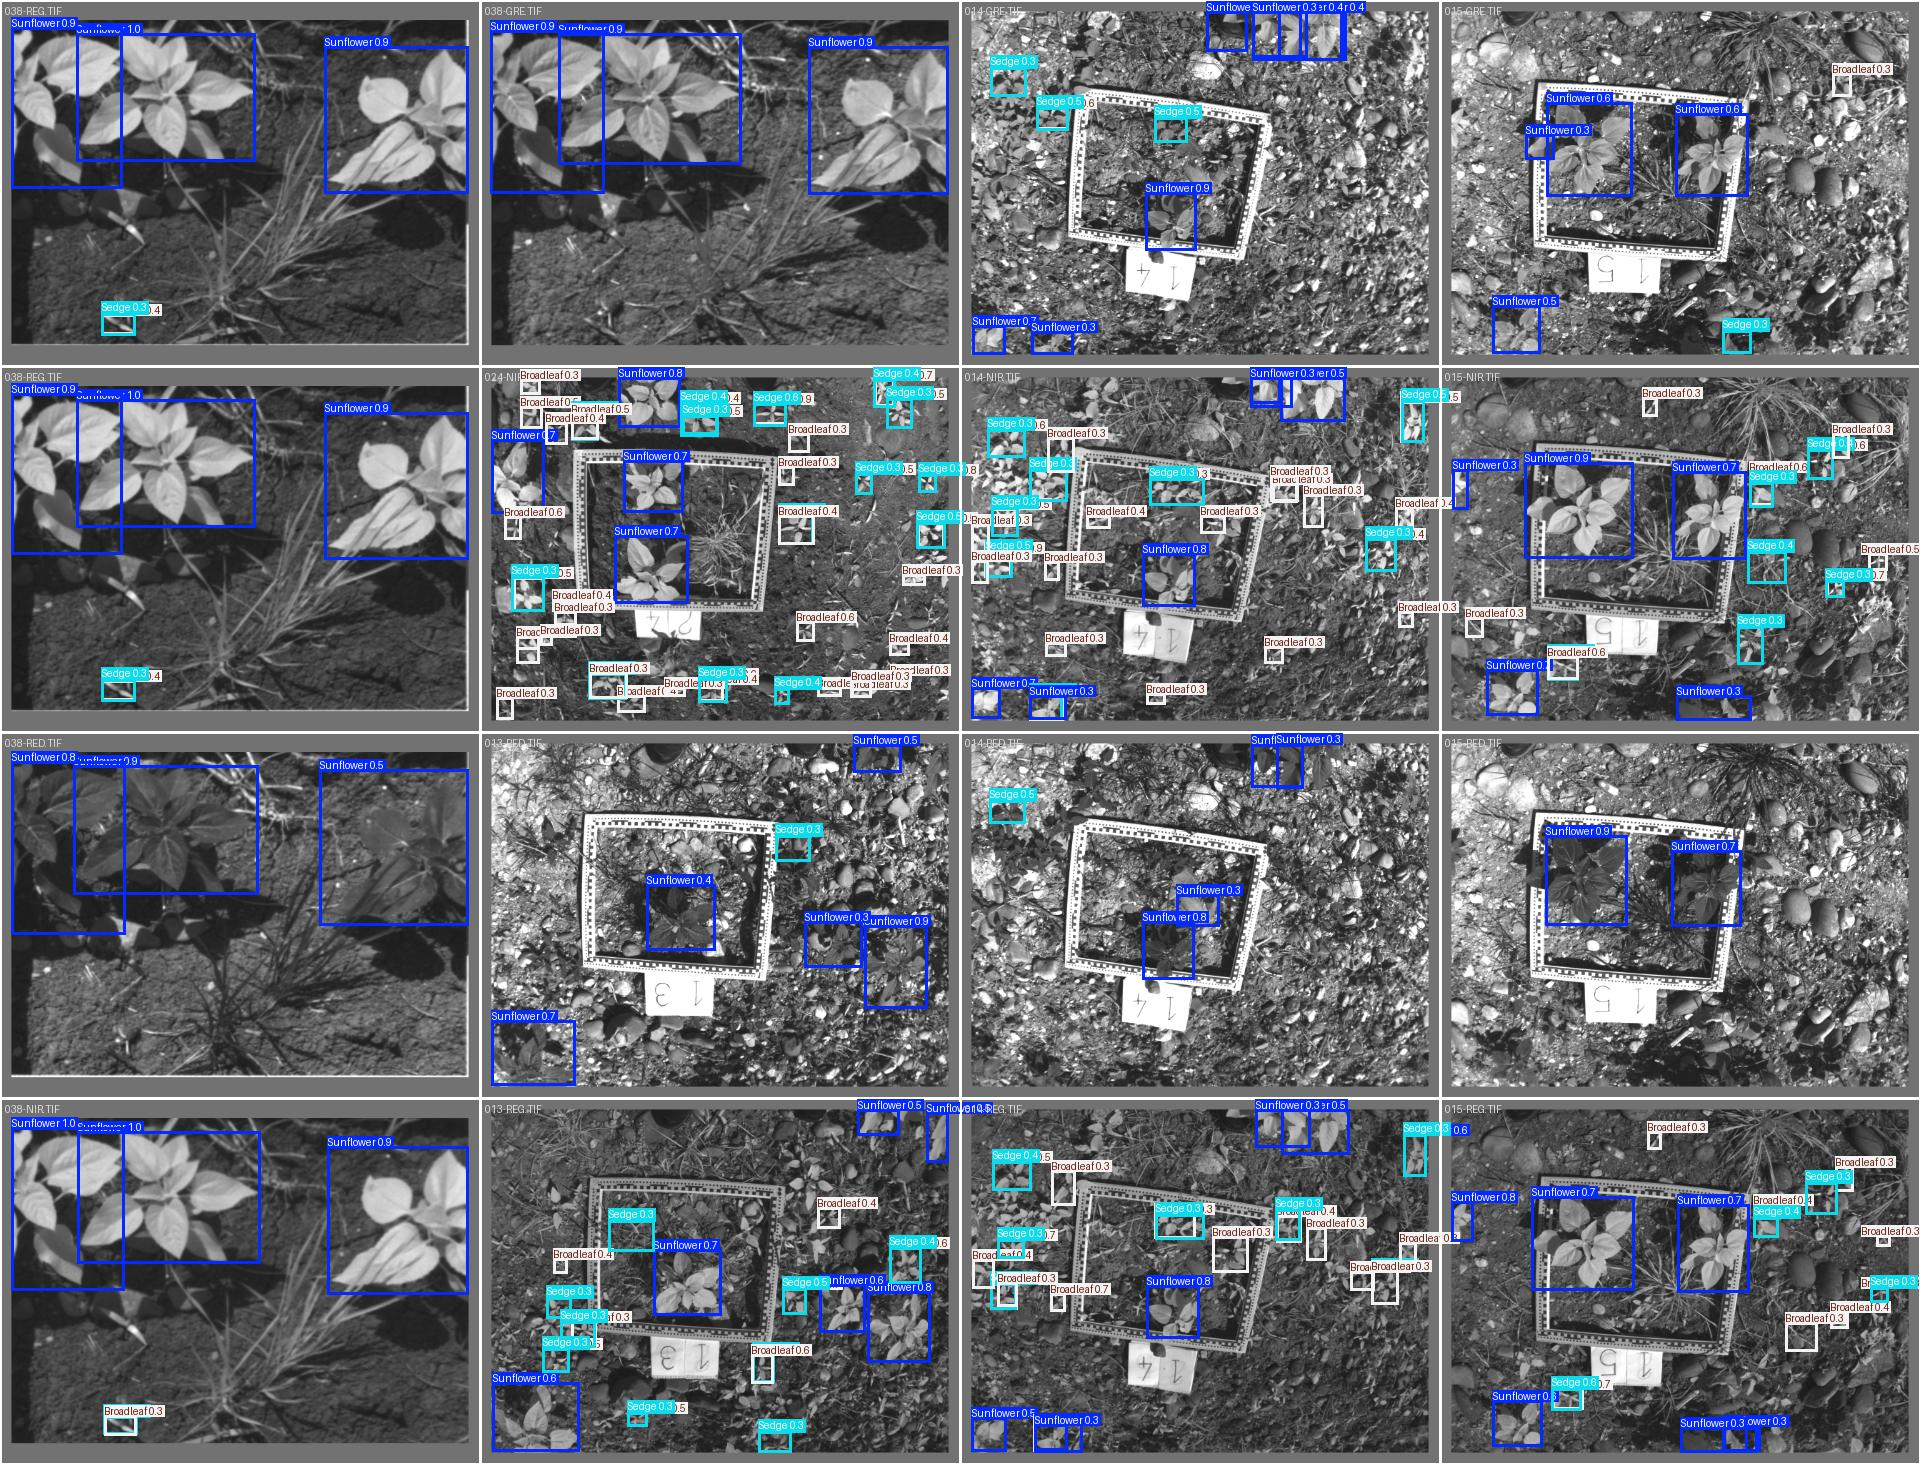

In [18]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train9/val_batch0_pred.jpg', width=600)

## Validate Custom Model

In [21]:
%cd {HOME}

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


In [22]:

!yolo task=detect mode=val model=C:/Users/PMLS/Desktop/best.pt data=NIRdataset.yaml


Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Model summary (fused): 168 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
                   all         67        533      0.305      0.163     0.0345     0.0203
             Sunflower         12         73      0.133      0.507     0.0985     0.0643
                 Sedge         10        156     0.0246     0.0449    0.00837      0.004
             Broadleaf         12        284     0.0647      0.102     0.0269     0.0119
             Bacground          2         20          1          0    0.00439   0.000878
Speed: 1.8ms preprocess, 73.6ms inference, 0.0ms loss, 37.1ms postprocess per image
Results saved to runs\detect\val
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/val



val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backgrounds, 0 corrupt: 100%|##########| 67/67 [00:00<?, ?it/s]
val: Scanning C:\Users\PMLS\Desktop\datasets\labels\val.cache... 13 images, 55 backgrounds, 0 corrupt: 100%|##########| 67/67 [00:00<?, ?it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):   0%|          | 0/5 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  20%|##        | 1/5 [00:02<00:08,  2.04s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  40%|####      | 2/5 [00:04<00:05,  1.99s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  60%|######    | 3/5 [00:06<00:04,  2.07s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95):  80%|########  | 4/5 [00:08<00:02,  2.10s/it]
                 Class     Images  Insta

In [20]:
%cd {HOME}

!yolo task=detect mode=val model={HOME}/runs/detect/train9/weights/best.pt data=NIRdataset.yaml

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\PMLS\anaconda3\Scripts\yolo.exe\__main__.py", line 7, in <module>
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\cfg\__init__.py", line 900, in entrypoint
    check_dict_alignment(full_args_dict, {a: ""})
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\cfg\__init__.py", line 485, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: 'ETC\Downloads\Yolo_Books_Mine\Yolo8' is not a valid YOLO argument. 

    Arguments received: ['yolo', 'task=detect', 'mode=val', 'model=C:\\Users\\PMLS\\Desktop\\ALL', 'ETC\\Downloads\\Yolo_Books_Mine\\Yolo8', 'NIR\\Ultra/runs/detect/train9/weights/best.pt', 'data=NIRdataset.yaml']. Ultralytics 'yolo' commands use the following syntax:

        yolo TASK MODE ARGS

        Where   TASK (optional) is one of {'segment', 'detect', 'classify',

## Inference with Custom Model

In [17]:
!yolo task=detect mode=predict model=C:/Users/PMLS/Desktop/best.pt source=C:/Users/PMLS/Desktop/test/images/ save=True

Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Model summary (fused): 218 layers, 25,841,497 parameters, 0 gradients, 78.7 GFLOPs

image 1/10 C:\Users\PMLS\Desktop\test\images\015-NIR.TIF: 480x640 4 Sunflowers, 12 Sedges, 19 Broadleafs, 471.9ms
image 2/10 C:\Users\PMLS\Desktop\test\images\016-NIR.TIF: 480x640 7 Sunflowers, 35 Broadleafs, 402.1ms
image 3/10 C:\Users\PMLS\Desktop\test\images\jesi_05_18__0_4min_rid_frame37.png: 480x640 1 Sunflower, 2 Broadleafs, 408.1ms
image 4/10 C:\Users\PMLS\Desktop\test\images\jesi_05_18__0_4min_rid_frame65.png: 480x640 1 Sedge, 1 Broadleaf, 408.5ms
image 5/10 C:\Users\PMLS\Desktop\test\images\jesi_05_18__0_4min_rid_frame71.png: 480x640 5 Sedges, 9 Broadleafs, 442.6ms
image 6/10 C:\Users\PMLS\Desktop\test\images\jesi_05_18__0_4min_rid_frame77.png: 480x640 1 Sunflower, 2 Sedges, 404.6ms
image 7/10 C:\Users\PMLS\Desktop\test\images\jesi_05_18__0_4min_rid_frame78.png: 480x640 1 Sunflower, 3 Sedges, 427.4ms
im

In [8]:
!yolo task=detect mode=predict model=C:/Users/PMLS/Desktop/best.pt source=C:/Users/PMLS/Desktop/test/Newimages/ save=True

Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Model summary (fused): 168 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame10.png: 480x640 1 Sunflower, 1 Sedge, 4 Broadleafs, 718.2ms
image 2/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame24.png: 480x640 2 Sunflowers, 5 Broadleafs, 351.1ms
image 3/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame25.png: 480x640 1 Sunflower, 3 Broadleafs, 339.0ms
image 4/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame26.png: 480x640 2 Sunflowers, 1 Broadleaf, 329.3ms
image 5/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame36.png: 480x640 2 Sunflowers, 2 Broadleafs, 344.7ms
image 6/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_18__0_4min_rid_frame37.png: 480x640 2 Broadleafs, 351.8ms
image 7/146 C:\Users\PMLS\Desktop\test\Newimages\jesi_05_

In [9]:
#%cd {HOME}
!yolo task=detect mode=predict model=C:/Users/PMLS/Desktop/best.pt source=C:/Users/PMLS/Desktop/test/images/ save=True

Ultralytics 8.3.40 ðŸš€ Python-3.12.7 torch-2.5.1+cpu CPU (12th Gen Intel Core(TM) i5-1235U)
Model summary (fused): 168 layers, 11,126,745 parameters, 0 gradients, 28.4 GFLOPs

image 1/4 C:\Users\PMLS\Desktop\test\images\013-GRE.TIF: 480x640 7 Sunflowers, 9 Sedges, 11 Broadleafs, 444.3ms
image 2/4 C:\Users\PMLS\Desktop\test\images\013-NIR.TIF: 480x640 7 Sunflowers, 11 Sedges, 41 Broadleafs, 347.0ms
image 3/4 C:\Users\PMLS\Desktop\test\images\013-RED.TIF: 480x640 7 Sunflowers, 7 Sedges, 6 Broadleafs, 365.7ms
image 4/4 C:\Users\PMLS\Desktop\test\images\013-REG.TIF: 480x640 7 Sunflowers, 13 Sedges, 37 Broadleafs, 372.5ms
Speed: 5.0ms preprocess, 382.4ms inference, 19.4ms postprocess per image at shape (1, 3, 480, 640)
Results saved to runs\detect\predict4
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


In [39]:
%cd {HOME}
!yolo task=detect mode=predict model={HOME}/runs/detect/train17/weights/best.pt source={HOME}/datasets/test/images save=True

C:\Users\PMLS\Desktop\ALL ETC\Downloads\Yolo_Books_Mine\Yolo8 NIR\Ultra


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\PMLS\anaconda3\Scripts\yolo.exe\__main__.py", line 7, in <module>
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\cfg\__init__.py", line 900, in entrypoint
    check_dict_alignment(full_args_dict, {a: ""})
  File "C:\Users\PMLS\anaconda3\Lib\site-packages\ultralytics\cfg\__init__.py", line 485, in check_dict_alignment
    raise SyntaxError(string + CLI_HELP_MSG) from e
SyntaxError: 'ETC\Downloads\Yolo_Books_Mine\Yolo8' is not a valid YOLO argument. 

    Arguments received: ['yolo', 'task=detect', 'mode=predict', 'model=C:\\Users\\PMLS\\Desktop\\ALL', 'ETC\\Downloads\\Yolo_Books_Mine\\Yolo8', 'NIR\\Ultra/runs/detect/train17/weights/best.pt', 'source=C:\\Users\\PMLS\\Desktop\\ALL', 'ETC\\Downloads\\Yolo_Books_Mine\\Yolo8', 'NIR\\Ultra/datasets/test/images', 'save=True']. Ultralytics 'yolo' commands use the following sy

**NOTE:** Let's take a look at few results.

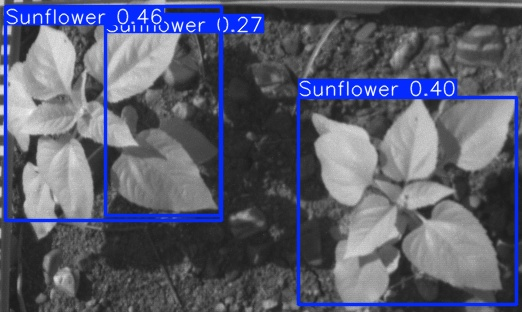

In [29]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/detect/predict/*.jpg')[:1]:
      display(Image(filename=image_path, width=600))
      print("\n")